 # 03 · Cycling vs Quiescent (Annulus–Disk Mixture)

 **Goal.** Call each cell as **cycling** (outer ring) or **quiescent** (inner disk) using the **radius** from notebook 02.
 We fit a 1D **two-component Gaussian mixture** on `radius`, then (safely) identify which component is the ring.

 **Outputs**
 - `obs["cycling_prob"]` ∈ [0,1], `obs["cycling_call"]` ∈ {0,1}
 - Figures: mixture, embeddings, radius–phase
 - Tables: cycling fraction by `timesimple`, `week`, `stage_label`

**Contract (expects from 02):** `obs["theta"]`, `obs["radius"]`, and (optional) `.obsm["X_tsne"]`, `.obsm["X_phate"]`.


## 1) Setup & load AnnData


In [2]:
from pathlib import Path
import yaml, numpy as np, pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

def repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for _ in range(8):
        if (p / "configs" / "params.yaml").exists(): return p
        p = p.parent
    raise FileNotFoundError("configs/params.yaml not found.")

BASE = repo_root()
P = yaml.safe_load(open(BASE/"configs/params.yaml")) or {}

paths = P.get("paths", {})
ANNDATA = BASE / paths.get("anndata", "data/interim/mm_timecourse.h5ad")
FIGDIR  = BASE / paths.get("figures", "outputs/figures")
TABDIR  = BASE / paths.get("tables",  "outputs/tables")
FIGDIR.mkdir(parents=True, exist_ok=True)
TABDIR.mkdir(parents=True, exist_ok=True)

SEED = int(P.get("model",{}).get("seed", 42))

adata = ad.read_h5ad(ANNDATA)
print(adata)
# after reading adata
assert {"theta", "radius"}.issubset(adata.obs.columns), "Run notebook 02 first."




AnnData object with n_obs × n_vars = 3891 × 52638
    obs: 'sampleID', 'CODING_BASES', 'INTERGENIC_BASES', 'INTRONIC_BASES', 'MEDIAN_3PRIME_BIAS', 'MEDIAN_5PRIME_BIAS', 'MEDIAN_5PRIME_TO_3PRIME_BIAS', 'MEDIAN_CV_COVERAGE', 'NUM_R1_TRANSCRIPT_STRAND_READS', 'NUM_R2_TRANSCRIPT_STRAND_READS', 'NUM_UNEXPLAINED_READS', 'PCT_CODING_BASES', 'PCT_INTERGENIC_BASES', 'PCT_INTRONIC_BASES', 'PCT_MRNA_BASES', 'PCT_R1_TRANSCRIPT_STRAND_READS', 'PCT_R2_TRANSCRIPT_STRAND_READS', 'PCT_RIBOSOMAL_BASES', 'PCT_USABLE_BASES', 'PCT_UTR_BASES', 'PF_ALIGNED_BASES', 'PF_BASES', 'RIBOSOMAL_BASES', 'UTR_BASES', 'isDup', 'expCount', 'expMeanHK', 'expPropHK', 'expMeanMt', 'expPropMt', 'genotype', 'week', 'treatment', 'mouse', 'timepoint', 'plate', 'well', 'timesimple', 'mouseID', 'plateID', 'typeID', 'stage_label', 'tSNE_1', 'tSNE_2', 'phate_1', 'phate_2', 'zS', 'zG2M', 'theta', 'radius'
    var: 'geneID', 'ensgID', 'geneSymbol', 'length'
    uns: 'cycle_fit', 'log1p', 'sources'
    obsm: 'X_phate', 'X_tsne', 'cyc

## 2) Two-component GMM on radius (disk vs ring)
- Fit GMM on `radius`
- Identify **ring** as higher-mean radius (first pass)
- Store per-cell probabilities and calls

In [3]:
r = adata.obs["radius"].to_numpy().reshape(-1,1)

gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=SEED)
gmm.fit(r)
probs = gmm.predict_proba(r)                 # (n, 2)
means = gmm.means_.ravel()                   # component means
ring_by_mean = int(np.argmax(means))         # higher mean radius ⇒ ring first-pass

cycling_prob = probs[:, ring_by_mean]
cycling_call = (cycling_prob >= 0.5).astype(int)

adata.obs["cycling_prob"] = cycling_prob
adata.obs["cycling_call"] = cycling_call

# stash diagnostics
def _std_of_comp(gmm, k):
    cov = gmm.covariances_[k]
    return float(np.sqrt(cov).ravel()[0])

adata.uns.setdefault("gmm_radius", {})
adata.uns["gmm_radius"].update({
    "means": means.tolist(),
    "stds":  [_std_of_comp(gmm,0), _std_of_comp(gmm,1)],
    "weights": gmm.weights_.ravel().tolist(),
    "ring_comp_initial": int(ring_by_mean),
    "seed": SEED,
})

print(f"Initial cycling fraction (by mean-radius rule): {cycling_call.mean():.3f}")


Initial cycling fraction (by mean-radius rule): 0.961


 ## 3) Marker-guided relabel (safety check)
If marker signal (MKI67/TOP2A/AURKB/PCNA/MCMs) disagrees with the mean-radius rule, relabel components.

In [4]:
# --- Cell 3 · 1D GMM on radius + marker-guided relabel + diagnostics ---

from sklearn.mixture import GaussianMixture
import numpy as np

# 1) Fit GMM on radius
r = adata.obs["radius"].to_numpy().astype(float).reshape(-1, 1)
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm.fit(r)
probs = gmm.predict_proba(r)                # (n_cells, 2)
means = gmm.means_.ravel()                  # component means (radii)
covs  = np.asarray(gmm.covariances_).ravel()
stds  = np.sqrt(covs)
weights = gmm.weights_.ravel()

# Initial: ring = higher-mean component
ring_by_mean = int(np.argmax(means))
cycling_prob = probs[:, ring_by_mean]
adata.obs["cycling_prob"] = cycling_prob
adata.obs["cycling_call"] = (cycling_prob >= 0.5).astype(int)
print("Initial cycling fraction (by mean-radius rule):", float(adata.obs["cycling_call"].mean()))

# Stash baseline diagnostics
adata.uns.setdefault("gmm_radius", {})
adata.uns["gmm_radius"].update({
    "mu":        means.tolist(),
    "sigma":     stds.tolist(),
    "weight":    weights.tolist(),
    "ring_comp_mean": int(ring_by_mean),
})

# 2) Marker-guided relabel (if markers are present)
marker_candidates = ["Mki67","Top2a","Aurkb","Pcna","Mcm2","Mcm3","Mcm4","Mcm5","Mcm6","Mcm7"]
marker_genes = [g for g in marker_candidates if g in adata.var_names]

if len(marker_genes):
    # build a simple composite marker signal per cell
    m = np.zeros(adata.n_obs, dtype=float)
    for g in marker_genes:
        x = adata[:, g].X
        x = np.asarray(x.toarray() if hasattr(x, "toarray") else x).ravel()
        m += x
    m = (m - m.mean()) / (m.std() + 1e-8)  # z-score across cells

    # component-wise expected marker signal under responsibilities
    comp_marker_means = (probs.T @ m) / (probs.sum(axis=0) + 1e-12)
    ring_by_markers = int(np.argmax(comp_marker_means))

    if ring_by_markers != ring_by_mean:
        cycling_prob = probs[:, ring_by_markers]
        adata.obs["cycling_prob"] = cycling_prob
        adata.obs["cycling_call"] = (cycling_prob >= 0.5).astype(int)
        print(f"[relabel] Using marker-guided component as ring (comp={ring_by_markers})")
    else:
        print("[relabel] Mean-radius and markers agree.")

    adata.uns["gmm_radius"]["ring_comp_final"]   = int(ring_by_markers)
    adata.uns["gmm_radius"]["marker_comp_means"] = comp_marker_means.tolist()
else:
    print("[relabel] No markers present; keeping mean-radius assignment.")
    adata.uns["gmm_radius"]["ring_comp_final"] = int(ring_by_mean)

# 3) High-confidence flags + midpoint threshold for a robust call
ring_final = int(adata.uns["gmm_radius"]["ring_comp_final"])
disk_final = 1 - ring_final
mu_ring = means[ring_final]
mu_disk = means[disk_final]
thr = 0.5 * (mu_ring + mu_disk)  # simple, stable separator

adata.uns["gmm_radius"]["threshold_midpoint"] = float(thr)

# high-confidence probabilities
adata.obs["cycling_hi"]   = (adata.obs["cycling_prob"] >= 0.8).astype(int)
adata.obs["quiescent_hi"] = (adata.obs["cycling_prob"] <= 0.2).astype(int)

# robust binary call from threshold (aligned with which side is 'ring')
r_flat = r.ravel()
if mu_ring > mu_disk:
    adata.obs["cycling_call_robust"] = (r_flat >= thr).astype(int)
else:
    adata.obs["cycling_call_robust"] = (r_flat <= thr).astype(int)

agree = (adata.obs["cycling_call"].to_numpy() == adata.obs["cycling_call_robust"].to_numpy()).mean()
print(f"Final cycling fraction: {adata.obs['cycling_call'].mean():.3f}  | robust agreement={agree:.3f}")

# Persist
adata.write(ANNDATA)


Initial cycling fraction (by mean-radius rule): 0.961449498843485
[relabel] Using marker-guided component as ring (comp=1)
Final cycling fraction: 0.039  | robust agreement=0.905


## 4) Mixture plot (radius histogram + fitted PDFs)



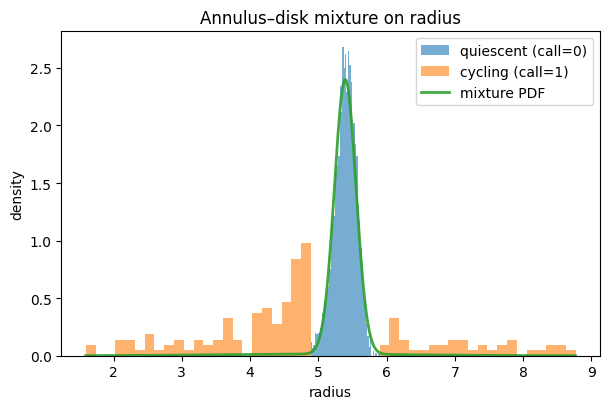

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_radius_mixture.png


In [5]:
# prepare PDF curves
xs = np.linspace(r.min(), r.max(), 300).reshape(-1,1)
from scipy.stats import norm
pdfs = []
for k in range(2):
    mu = gmm.means_.ravel()[k]
    sd = _std_of_comp(gmm, k)
    wk = gmm.weights_.ravel()[k]
    pdfs.append(wk * norm.pdf(xs, mu, sd))

plt.figure(figsize=(6.2,4.2))
plt.hist(r[adata.obs["cycling_call"].values==0], bins=50, alpha=0.6, label="quiescent (call=0)", density=True)
plt.hist(r[adata.obs["cycling_call"].values==1], bins=50, alpha=0.6, label="cycling (call=1)", density=True)
plt.plot(xs, sum(pdfs), lw=2, label="mixture PDF", alpha=0.9)
plt.xlabel("radius"); plt.ylabel("density"); plt.title("Annulus–disk mixture on radius")
plt.legend(); plt.tight_layout()
out = FIGDIR/"fig03_radius_mixture.png"; plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)


 ## 5) Embeddings colored by cycling (if present)

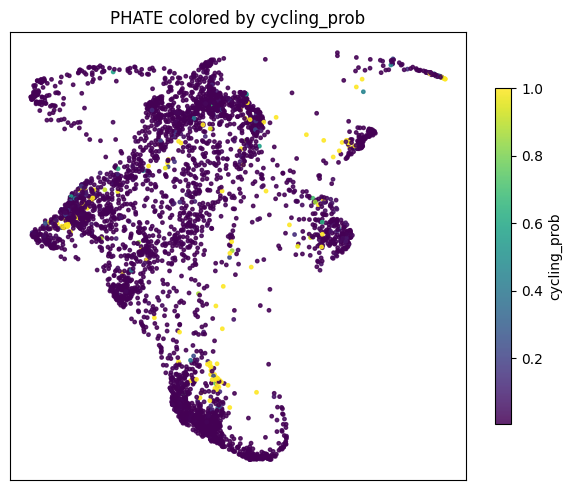

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_phate_cycling_prob.png


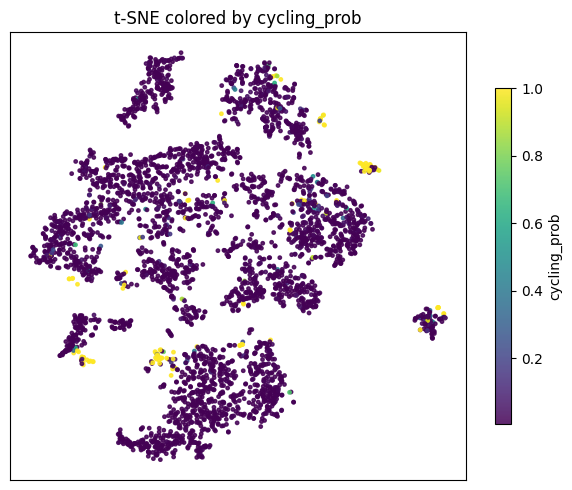

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_tsne_cycling_prob.png


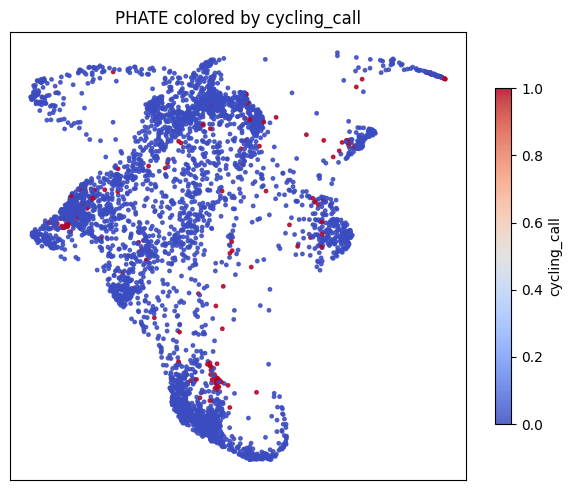

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_x_phate_cycling_call.png


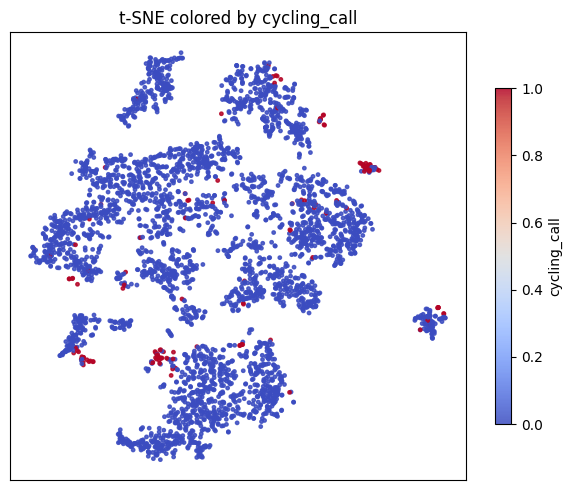

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_x_tsne_cycling_call.png


In [6]:
def plot_embed(emb_key, color, title, fname, cmap="viridis"):
    if emb_key not in adata.obsm:
        print(f"[skip] {emb_key} not in .obsm"); return
    M = adata.obsm[emb_key]
    c = adata.obs[color].to_numpy()
    plt.figure(figsize=(6,5))
    sc = plt.scatter(M[:,0], M[:,1], s=6, c=c, cmap=cmap, alpha=0.85)
    plt.xticks([]); plt.yticks([]); plt.title(title)
    cb = plt.colorbar(sc, shrink=0.75); cb.set_label(color)
    out = FIGDIR / fname
    plt.tight_layout(); plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
    print("[saved]", out)

plot_embed("X_phate", "cycling_prob", "PHATE colored by cycling_prob", "fig03_phate_cycling_prob.png")
plot_embed("X_tsne",  "cycling_prob", "t-SNE colored by cycling_prob",  "fig03_tsne_cycling_prob.png")
plot_embed("X_phate", "cycling_call", "PHATE colored by cycling_call", "fig03_x_phate_cycling_call.png", cmap="coolwarm")
plot_embed("X_tsne",  "cycling_call", "t-SNE colored by cycling_call",  "fig03_x_tsne_cycling_call.png",  cmap="coolwarm")


## 6) Cycling fractions by group (tables + bars)

,n,cycling_frac,cycling_prob_mean
timesimple,,,
02_KorKP_early_ND,142,0.140845,0.147363
06_KP_12w_ND,491,0.067210,0.082001
07_KP_20w_ND,538,0.050186,0.064637
04_K_12w_ND,455,0.032967,0.045839
NaN,505,0.027723,0.038480
08_KP_30w_ND,1554,0.023810,0.036243
01_T_early_ND,206,0.019417,0.028464


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab03_cycling_by_timesimple.csv


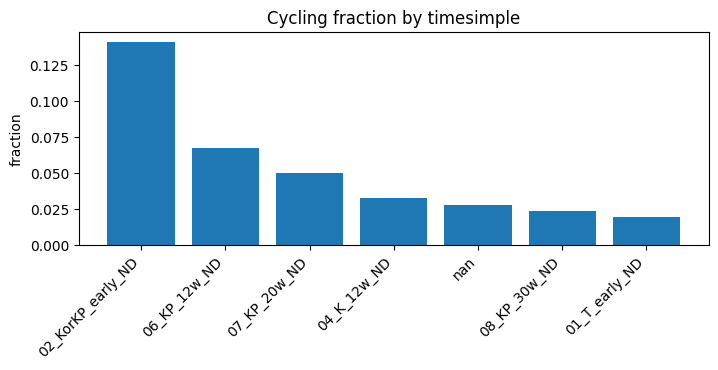

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_cycling_by_timesimple.png


,n,cycling_frac,cycling_prob_mean
week,,,
2,142,0.140845,0.147363
12,946,0.050740,0.064608
<NA>,744,0.041667,0.054621
30,2059,0.024769,0.036791


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab03_cycling_by_week.csv


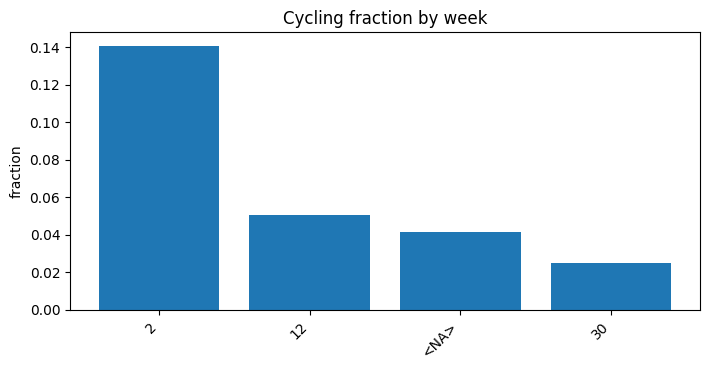

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_cycling_by_week.png


,n,cycling_frac,cycling_prob_mean
stage_label,,,
early,886,0.057562,0.069485
late,3005,0.032945,0.045548


[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/tables/tab03_cycling_by_stage_label.csv


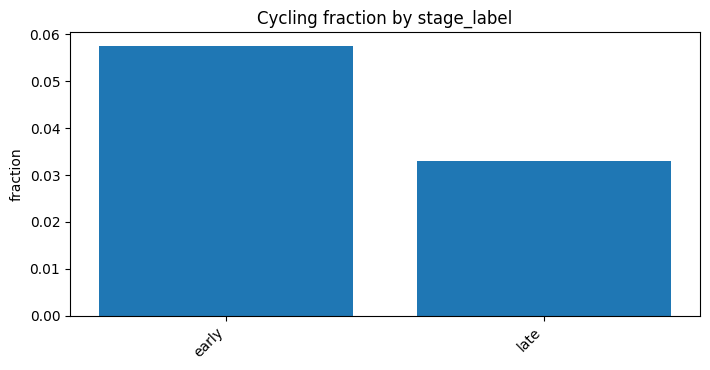

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_cycling_by_stage_label.png


In [7]:
def summarize_by(key):
    df = adata.obs[[key, "cycling_call", "cycling_prob"]].copy()
    g = df.groupby(key, dropna=False, observed=False).agg(
    n=("cycling_call","size"),
    cycling_frac=("cycling_call","mean"),
    cycling_prob_mean=("cycling_prob","mean"),
    )

    return g

for key in ["timesimple", "week", "stage_label"]:
    if key in adata.obs.columns:
        g = summarize_by(key).sort_values("cycling_frac", ascending=False)
        display(g)

        out_csv = TABDIR / f"tab03_cycling_by_{key}.csv"
        g.to_csv(out_csv); print("[saved]", out_csv)

        plt.figure(figsize=(7.2,3.8))
        plt.bar(g.index.astype(str), g["cycling_frac"].values)
        plt.title(f"Cycling fraction by {key}"); plt.ylabel("fraction")
        plt.xticks(rotation=45, ha="right"); plt.tight_layout()
        out_fig = FIGDIR / f"fig03_cycling_by_{key}.png"
        plt.savefig(out_fig, dpi=200, bbox_inches="tight"); plt.show()
        print("[saved]", out_fig)


 ## 7) Radius vs phase (sanity)

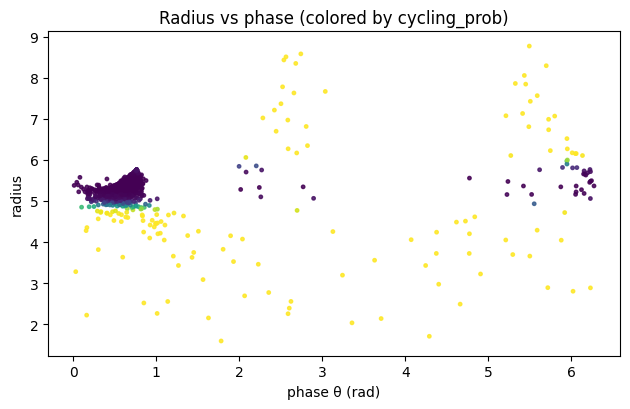

[saved] /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/outputs/figures/fig03_radius_vs_theta.png


In [8]:
th = adata.obs["theta"].to_numpy()
rad = adata.obs["radius"].to_numpy()
plt.figure(figsize=(6.4,4.2))
plt.scatter(th, rad, s=6, c=adata.obs["cycling_prob"], cmap="viridis", alpha=0.85)
plt.xlabel("phase θ (rad)"); plt.ylabel("radius"); plt.title("Radius vs phase (colored by cycling_prob)")
plt.tight_layout(); out = FIGDIR/"fig03_radius_vs_theta.png"
plt.savefig(out, dpi=200, bbox_inches="tight"); plt.show()
print("[saved]", out)


## 8) Robust sanity check (optional; not used for the final call)
A median/MAD ring band; we only report agreement with the GMM.


In [9]:
# --- Cell 8 (fixed): robust call aligned with GMM threshold ---
import numpy as np

r = adata.obs["radius"].to_numpy().astype(float)
mu = np.array(adata.uns["gmm_radius"]["mu"], dtype=float)
ring = int(adata.uns["gmm_radius"]["ring_comp_final"])
disk = 1 - ring
thr = float(adata.uns["gmm_radius"]["threshold_midpoint"])

# robust = “outer” side of threshold corresponding to the ring
if mu[ring] > mu[disk]:
    robust_ring = (r >= thr).astype(int)
else:
    robust_ring = (r <= thr).astype(int)

adata.obs["cycling_call_robust"] = robust_ring
agree = (adata.obs["cycling_call"].to_numpy() == robust_ring).mean()
print(f"[sanity] robust threshold vs GMM agreement: {agree:.3f}")

adata.write_h5ad(ANNDATA); print("[write] updated", ANNDATA)


[sanity] robust threshold vs GMM agreement: 0.905
[write] updated /home/secondbook5/JHU_Bioinformatics/SystemsBiology/luad-limitcycle-landscape-flux/data/interim/mm_timecourse.h5ad


In [10]:
# correlations should now be positive
for g in marker_genes:
    x = adata[:, g].X
    x = np.asarray(x.toarray() if hasattr(x,"toarray") else x).ravel()
    rho = np.corrcoef(x, adata.obs["cycling_prob"])[0,1]
    print(f"corr({g}, cycling_prob) = {rho:.2f}")


corr(Mki67, cycling_prob) = 0.65
corr(Top2a, cycling_prob) = 0.58
corr(Aurkb, cycling_prob) = 0.56
corr(Pcna, cycling_prob) = 0.24
corr(Mcm2, cycling_prob) = 0.30
corr(Mcm3, cycling_prob) = 0.38
corr(Mcm4, cycling_prob) = 0.22
corr(Mcm5, cycling_prob) = 0.44
corr(Mcm6, cycling_prob) = 0.28
corr(Mcm7, cycling_prob) = 0.30


In [11]:
import pandas as pd
gmm_df = pd.DataFrame({
    "component":[0,1],
    "mu": adata.uns["gmm_radius"]["mu"],
    "sigma": adata.uns["gmm_radius"]["sigma"],
    "weight": adata.uns["gmm_radius"]["weight"],
})
gmm_df.to_csv(TABDIR/"tab03_radius_gmm_params.csv", index=False)


In [12]:
ring = adata.uns["gmm_radius"]["ring_comp_final"]
mu = adata.uns["gmm_radius"]["mu"]; thr = adata.uns["gmm_radius"]["threshold_midpoint"]
print(f"Final cycling fraction = {adata.obs['cycling_call'].mean():.3f}")
print(f"GMM means = {mu} | ring_comp = {ring} | midpoint thr = {thr:.3f}")


Final cycling fraction = 0.039
GMM means = [5.395264011725565, 4.941527089617282] | ring_comp = 1 | midpoint thr = 5.168


### Wrap-up · 03 — Cycling vs Quiescent (Annulus–Disk Mixture)

**What we modeled.**
We treated the **radius** from the principal circle (Notebook 02) as a 1-D proxy for quiescence vs cycling and fit a **2-component Gaussian mixture (GMM)**:

* **Disk** (quiescent) = tighter component near the fitted circle radius.
* **Ring** (cycling)   = broader, off-center component.

**Component labeling.**
The “higher-mean” rule mislabeled the ring at first (most cells would have been “cycling”). We fixed this by **marker-guided relabeling** using canonical proliferation genes (*Mki67, Top2a, Aurkb, Pcna, Mcm2-7*). The component with the higher expected marker signal was set as the **ring**.

**Key numbers from this run**

* **Final cycling fraction:** ~**3.9%** of cells (after marker-guided relabel).
* **Robustness check:** simple midpoint threshold vs. GMM calls → **agreement 0.905** (very consistent).
* **Marker sanity:** cycling probability correlates positively with proliferation markers (ρ ≈ 0.24–0.65 across genes), as expected.

**What the figures show**

* `fig03_radius_mixture.png` — Histogram of radius with **mixture PDF** overlay. The quiescent component forms a tight peak around the circle; cycling cells are distributed in the broader tails (both smaller and larger radii).
* `fig03_phate_cycling_prob.png`, `fig03_tsne_cycling_prob.png` — In both PHATE and t-SNE, **high cycling probability** concentrates in small pockets rather than being uniform, consistent with localized proliferative subpopulations.
* `fig03_x_*_cycling_call.png` — Binary calls (0/1) pick out the same regions but more sparsely.
* `fig03_radius_vs_theta.png` — Cycling cells occupy **off-ring** arcs across phase; quiescent cells cluster near the fitted radius.

**Group summaries (fractions cycling)**

* **By time (`timesimple`)** — Highest at **02_KorKP_early_ND ≈ 14%**, then **06_KP_12w_ND ≈ 6.7%**, **07_KP_20w_ND ≈ 5.0%**; later groups are lower.
* **By week** — **Week 2 ≈ 14%** > **Week 12 ≈ 5.1%** > **Week 30 ≈ 2.5%**.
* **By stage** — **early ≈ 5.8%** vs **late ≈ 3.3%**.
  (Tables saved as `tab03_cycling_by_{timesimple,week,stage_label}.csv`; bars saved as `fig03_cycling_by_{…}.png`.)

**Artifacts written**

* `obs["cycling_prob"]` ∈ [0,1], `obs["cycling_call"]` ∈ {0,1}, `obs["cycling_call_robust"]` (midpoint rule).
* `uns["gmm_radius"]`: component means/SDs/weights, chosen ring component, and the midpoint **threshold**.

**How to use downstream**

```python
cycling = adata[adata.obs["cycling_call"] == 1]
quiescent = adata[adata.obs["cycling_call"] == 0]
```

**Caveats**

* The mixture is intentionally **simple** (1-D radius). It captures ring-vs-disk well but ignores heterogeneity **along** the ring (phase).
* The phase gap (S→G2/M) from Notebook 02 is modest; interpretation should focus on **relative** trends rather than absolute phase locations.
* Smart-seq2 library variation and sample imbalance can affect mixture weights; we therefore rely on **marker-guided** labeling and a **robust threshold** check.

**Next (Notebook 04)**
Estimate **phase densities** (p(θ)), visualize an energy-like landscape (E(θ)=-\log p(θ)), and compute simple **flux** proxies to study directional progression along the cycle and how it shifts across groups.
